In [10]:
## importing necessary packages & dataset


import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/datasets/diabetes_binary_health_indicators_BRFSS2015.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# 01
# Train test split, dropping Y (label)
df = pd.read_csv(file_path)
x = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

print("train : ", xtrain.shape)
print("test : ", xtest.shape)

print("train ratio : ")
print(ytrain.value_counts(normalize=True))
print("test ratio : ")
print(ytest.value_counts(normalize=True))




print(list(df.columns))
df.head(20)

train :  (202944, 21)
test :  (50736, 21)
train ratio : 
Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64
test ratio : 
Diabetes_binary
0.0    0.860671
1.0    0.139329
Name: proportion, dtype: float64
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [12]:
# 02 Check for Null values

print('Checking for null values:')
print(df.isnull().sum())

Checking for null values:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [13]:
# 02 Check for Total Null values

print('Checking for null values:')
print(df.isnull().sum().sum())

Checking for null values:
0


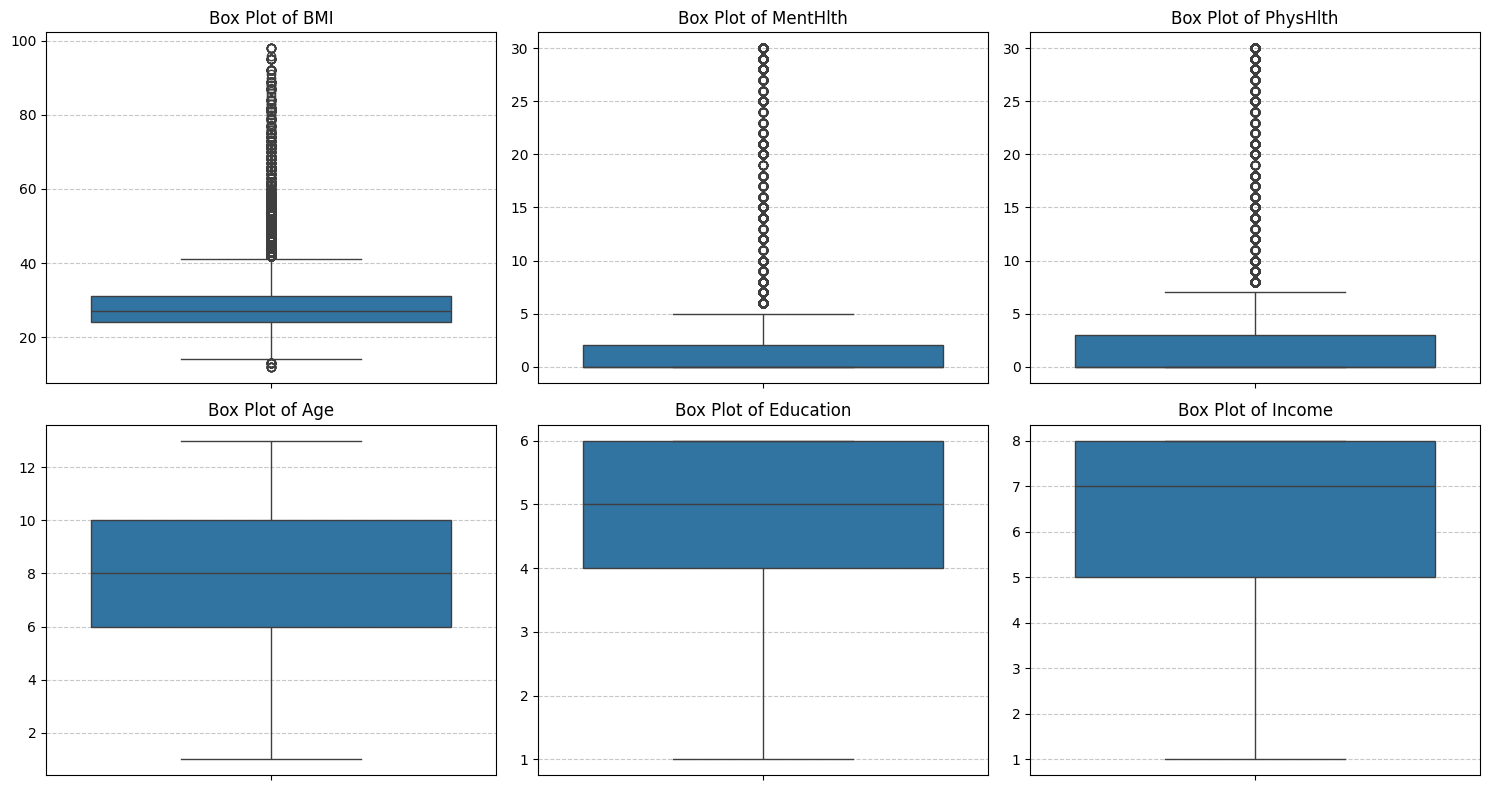

In [14]:
# 03 EDA - Exploratory Data Analysis / BoxPlots

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for box plots
# numerical_cols = df.select_dtypes(include=['number']).columns (Returns Numeric Only Columns)
numerical_cols = [col for col in df.columns if df[col].nunique() > 5] # (Returns Numeric Only Columns with at least more than 5 unique values)

# Determine the number of rows and columns for the subplot grid
num_features = len(numerical_cols)
num_rows = (num_features + 2) // 3 # Roughly 3 plots per row
num_cols = 3

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [15]:
## download splitted datasets

from google.colab import files

trainbalanced= pd.DataFrame(xtrain, columns = x.columns)
trainbalanced['Diabetes_binary']= ytrain

testrealdf = pd.DataFrame(xtest, columns = x.columns)
testrealdf['Diabetes_binary']= ytest

trainbalanced.to_csv('train.csv', index=False)
testrealdf.to_csv('testreal.csv', index=False)

files.download('train.csv')
files.download('testreal.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>